# NB00 — Gene List Profile

**Type:** Confirmatory (data profiling / pre-analysis characterisation)  
**Status:** PENDING EXECUTION  

Profile the 730-KO comprehensive metal-resistance gene list.
Produces `data/gene_list_summary.csv` for downstream notebooks.

## Outputs
- `data/gene_list_summary.csv` — per-subset KO counts and metal coverage
- Summary tables and figures displayed inline

## Pre-specifications
- No statistical tests; purely descriptive.
- All numbers must be reproducible from the locked gene list CSV.
- Report tier counts, metal coverage per tier, functional category breakdown.


In [1]:
import sys
from pathlib import Path

# Make scripts importable from notebook
_project_root = Path().resolve().parent
if str(_project_root / 'scripts') not in sys.path:
    sys.path.insert(0, str(_project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from scripts.gene_list_utils import (
    load_gene_list,
    get_subset,
    get_metal_subset,
    list_metals_with_min_kos,
    subset_summary,
    _register_metal_subsets,
    SUBSET_REGISTRY,
)

pd.set_option('display.max_rows', 60)
pd.set_option('display.max_columns', 30)
print('Imports OK')

Imports OK


## 1. Load gene list

In [2]:
gl = load_gene_list()
_register_metal_subsets(gl)

print(f'Total KOs: {len(gl)}')
print(f'Columns: {list(gl.columns)}')
gl.head(3)

Total KOs: 730
Columns: ['KO', 'gene_name', 'definition', 'ec', 'primary_category', 'is_resistance', 'is_transport', 'is_sensor', 'is_cofactor', 'is_metabolism', 'overlap_flag', 'pfam_ids', 'pfam_metal', 'evidence_tier', 'tier_1_vs_2', 'metals', 'metal_sources', 'source_kegg_module', 'source_bacmet', 'source_fitness', 'notes']


,KO,gene_name,definition,ec,primary_category,is_resistance,is_transport,is_sensor,is_cofactor,is_metabolism,overlap_flag,pfam_ids,pfam_metal,evidence_tier,tier_1_vs_2,metals,metal_sources,source_kegg_module,source_bacmet,source_fitness,notes
0,K00013,hisD,histidinol dehydrogenase [EC:1.1.1.23],1.1.1.23,Metal-dependent Metabolism,False,False,False,False,True,False,NaN,False,Tier 2-Fitness,Tier 2,"Co,Ni","fitness:Co,fitness:Ni",NaN,NaN,yes,NaN
1,K00024,mdh,malate dehydrogenase [EC:1.1.1.37],1.1.1.37,Metal-dependent Metabolism,False,False,False,False,True,False,NaN,False,Tier 3,Tier 2,S,module:sulfur,M00614,NaN,NaN,flagged for manual review
2,K00031,IDH1,isocitrate dehydrogenase [EC:1.1.1.42],1.1.1.42,Metal-dependent Metabolism,False,False,False,False,True,False,NaN,False,Tier 3,Tier 2,S,module:sulfur,M00614,NaN,NaN,flagged for manual review


## 2. Evidence-tier counts

**Expected:** Tier 1=32, Tier 2=108, Tier 2-Fitness=116, Tier 3=286, Tier 3-BacMet=188

In [3]:
tier_counts = gl['evidence_tier'].value_counts().reindex(
    ['Tier 1', 'Tier 2', 'Tier 2-Fitness', 'Tier 3', 'Tier 3-BacMet']
)
print('Evidence-tier counts:')
print(tier_counts.to_string())
assert tier_counts.sum() == 730, f'Expected 730 total KOs, got {tier_counts.sum()}'
print('\nAssertion passed: 730 KOs total')

Evidence-tier counts:
evidence_tier
Tier 1             32
Tier 2            108
Tier 2-Fitness    116
Tier 3            286
Tier 3-BacMet     188

Assertion passed: 730 KOs total


## 3. Functional category breakdown

In [4]:
cat_counts = gl['primary_category'].value_counts()
print('Functional category counts:')
print(cat_counts.to_string())

tier1v2 = gl['tier_1_vs_2'].value_counts()
print('\nFunctional tier (tier_1_vs_2) counts:')
print(tier1v2.to_string())

Functional category counts:
primary_category
Unknown                       302
Transport/Homeostasis         213
Resistance/Detoxification     106
Metal-dependent Metabolism     54
Sensing/Regulation             48
Cofactor Biosynthesis           7

Functional tier (tier_1_vs_2) counts:
tier_1_vs_2
Tier 2     322
Unknown    302
Tier 1     106


## 4. Metal coverage

In [5]:
all_metals = list_metals_with_min_kos(gl, min_kos=1)
primary_metals = list_metals_with_min_kos(gl, min_kos=20)

print(f'Distinct metals in gene list: {len(all_metals)}')
print(f'Metals with >=20 KOs: {len(primary_metals)}')
print('\nMetals with >=20 KOs:')
for sym, n in primary_metals.items():
    print(f'  {sym}: {n}')

Distinct metals in gene list: 24
Metals with >=20 KOs: 9

Metals with >=20 KOs:
  Co: 101
  Fe: 98
  Ni: 84
  S: 74
  Cu: 71
  Zn: 67
  Tl: 45
  Al: 34
  Mn: 34


## 5. Named subset counts

In [6]:
ss = subset_summary(gl)
print('All named subsets:')
display(ss)

All named subsets:


,subset,n_kos,description
1,all_non_ambiguous,444,evidence_tier ≠ Tier 3 — excludes KEGG-ambigu...
15,primary_functional,428,"tier_1_vs_2 ∈ {Tier 1, Tier 2} — all function..."
9,functional_tier2,322,tier_1_vs_2 == Tier 2 (= all other functional...
22,transport,213,primary_category == Transport/Homeostasis — i...
2,bacmet_only,188,evidence_tier == Tier 3-BacMet — 188 KOs; Bac...
14,primary,140,"evidence_tier ∈ {Tier 1, Tier 2} — 140 KOs; h..."
13,overlap_excluded,134,primary subset minus dual-function KOs (overla...
7,fitness_only,116,evidence_tier == Tier 2-Fitness — 116 KOs; em...
20,tier2_only,108,evidence_tier == Tier 2 — 108 KOs; clear KEGG...
8,functional_tier1,106,tier_1_vs_2 == Tier 1 (= Resistance/Detoxific...


## 6. Tier 1 KOs — canonical metal resistance genes

All 32 Tier 1 KOs should include czcABC, cusABCRS, zntA, merR, znuABC, sitABCD etc.

In [7]:
tier1 = get_subset('tier1_only', gl)
print(f'Tier 1 KOs: {len(tier1)}')
display(tier1[['KO', 'gene_name', 'definition', 'metals', 'primary_category']].sort_values('metals'))

Tier 1 KOs: 32


,KO,gene_name,definition,metals,primary_category
212,K03325,ACR3,arsenite transporter,"As,Tl",Resistance/Detoxification
513,K16264,czcD,cobalt-zinc-cadmium efflux system protein,"Cd,Co,Zn,Tl",Resistance/Detoxification
374,K08970,rcnA,nickel/cobalt transporter (NicO) family protein,"Co,Ni",Transport/Homeostasis
507,K15726,czcA,heavy metal efflux system protein,"Co,Ni,Zn,Cd",Resistance/Detoxification
508,K15727,czcB,"membrane fusion protein, heavy metal efflux sy...","Co,Ni,Zn,Cd",Resistance/Detoxification
325,K07644,cusS,"two-component system, OmpR family, heavy metal...",Cu,Sensing/Regulation
337,K07787,cusA,copper/silver efflux system protein,"Cu,Ag",Resistance/Detoxification
342,K07798,cusB,"membrane fusion protein, copper/silver efflux ...","Cu,Ag,Zn",Resistance/Detoxification
585,K19594,gesB,gold/copper resistance efflux pump,"Cu,Au",Resistance/Detoxification
586,K19595,gesA,"membrane fusion protein, gold/copper resistanc...","Cu,Au",Resistance/Detoxification


## 7. Source overlap (Tier 1 cross-validation)

Tier 1 KOs should all have source_bacmet=True AND source_fitness=True.

In [8]:
source_cols = [c for c in gl.columns if c.startswith('source_')]
print(f'Source columns: {source_cols}')

tier1_sources = tier1[source_cols + ['KO', 'gene_name']]
print('\nTier 1 source coverage:')
for col in source_cols:
    n_true = tier1[col].notna().sum() if tier1[col].dtype == object else tier1[col].sum()
    print(f'  {col}: {n_true}/{len(tier1)}')

Source columns: ['source_kegg_module', 'source_bacmet', 'source_fitness']

Tier 1 source coverage:
  source_kegg_module: /32
  source_bacmet: yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyes/32
  source_fitness: yesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyesyes/32


## 8. Per-tier metal coverage breakdown

In [9]:
def metals_for_tier(tier_label):
    sub = gl[gl['evidence_tier'] == tier_label]
    return list_metals_with_min_kos(sub, min_kos=1)

rows = []
for tier in ['Tier 1', 'Tier 2', 'Tier 2-Fitness', 'Tier 3', 'Tier 3-BacMet']:
    metals = metals_for_tier(tier)
    rows.append({'evidence_tier': tier,
                 'n_kos': int(gl['evidence_tier'].eq(tier).sum()),
                 'n_metals': len(metals),
                 'metals': ', '.join(metals.keys())})

tier_metal_df = pd.DataFrame(rows)
display(tier_metal_df)

,evidence_tier,n_kos,n_metals,metals
0,Tier 1,32,13,"Zn, Fe, Ni, Cu, Co, Mn, Cd, Hg, Tl, Ag, Au, Pb..."
1,Tier 2,108,12,"Fe, Zn, Mn, Co, Cu, S, Ni, Mo, Al, Tl, Ag, Bi"
2,Tier 2-Fitness,116,12,"Ni, Tl, Cu, Co, Al, Zn, Fe, Bi, Mn, Cr, K, Cd"
3,Tier 3,286,5,"S, Fe, Co, Mo, Zn"
4,Tier 3-BacMet,188,20,"Cu, Ni, Co, Mo, As, Hg, Mn, Zn, Mg, Cr, Ag, W,..."


## 9. Figure — tier composition bar chart

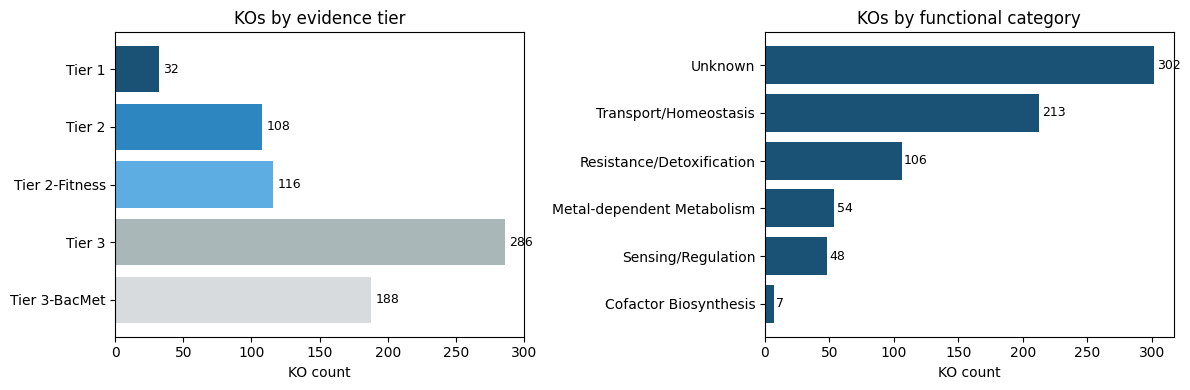

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Evidence tier counts
ax = axes[0]
tier_order = ['Tier 1', 'Tier 2', 'Tier 2-Fitness', 'Tier 3', 'Tier 3-BacMet']
colors = ['#1a5276', '#2e86c1', '#5dade2', '#aab7b8', '#d7dbdd']
vals = [int(gl['evidence_tier'].eq(t).sum()) for t in tier_order]
bars = ax.barh(tier_order[::-1], vals[::-1], color=colors[::-1])
ax.set_xlabel('KO count')
ax.set_title('KOs by evidence tier')
for bar, v in zip(bars, vals[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2,
            str(v), va='center', fontsize=9)

# Functional category counts
ax2 = axes[1]
cat_vals = cat_counts.sort_values(ascending=True)
ax2.barh(cat_vals.index, cat_vals.values, color='#1a5276')
ax2.set_xlabel('KO count')
ax2.set_title('KOs by functional category')
for i, v in enumerate(cat_vals.values):
    ax2.text(v + 2, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../figures/00_gene_list_tier_composition.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Figure — metal × tier heatmap

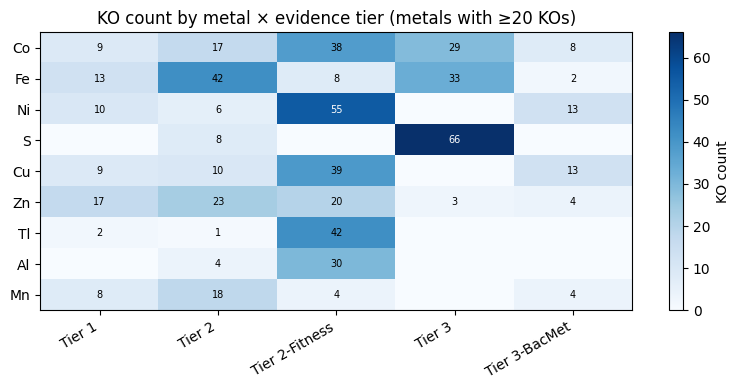

In [11]:
# Build metal × tier count matrix
metal_syms = list(primary_metals.keys())  # metals with >=20 KOs
tier_labels = ['Tier 1', 'Tier 2', 'Tier 2-Fitness', 'Tier 3', 'Tier 3-BacMet']

mat = np.zeros((len(metal_syms), len(tier_labels)), dtype=int)
for i, sym in enumerate(metal_syms):
    metal_kos = get_metal_subset(sym, gl)
    for j, tier in enumerate(tier_labels):
        mat[i, j] = int((metal_kos['evidence_tier'] == tier).sum())

fig, ax = plt.subplots(figsize=(8, max(4, len(metal_syms) * 0.35)))
im = ax.imshow(mat, aspect='auto', cmap='Blues')
ax.set_xticks(range(len(tier_labels)))
ax.set_xticklabels(tier_labels, rotation=30, ha='right')
ax.set_yticks(range(len(metal_syms)))
ax.set_yticklabels(metal_syms)
ax.set_title('KO count by metal × evidence tier (metals with ≥20 KOs)')
plt.colorbar(im, ax=ax, label='KO count')
# Annotate cells
for i in range(len(metal_syms)):
    for j in range(len(tier_labels)):
        if mat[i, j] > 0:
            ax.text(j, i, str(mat[i, j]), ha='center', va='center',
                    fontsize=7, color='black' if mat[i, j] < mat.max() * 0.7 else 'white')
plt.tight_layout()
plt.savefig('../figures/00_metal_tier_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Overlap flag check

Dual-function KOs (overlap_flag=True) in the primary subset — these carry
both resistance and metabolic/transport roles.  Report count for transparency.

In [12]:
primary = get_subset('primary', gl)
overlap_excl = get_subset('overlap_excluded', gl)

n_overlap = primary['overlap_flag'].sum()
print(f'Primary set: {len(primary)} KOs')
print(f'  overlap_flag=True: {n_overlap} KOs ({100*n_overlap/len(primary):.1f}%)')
print(f'Overlap-excluded primary: {len(overlap_excl)} KOs')
if n_overlap > 0:
    display(primary[primary['overlap_flag']][['KO', 'gene_name', 'primary_category', 'metals']])

Primary set: 140 KOs
  overlap_flag=True: 6 KOs (4.3%)
Overlap-excluded primary: 134 KOs


,KO,gene_name,primary_category,metals
22,K00240,sdhB,Sensing/Regulation,"Fe,S"
26,K00245,frdB,Sensing/Regulation,"Fe,S"
327,K07665,cusR,Resistance/Detoxification,"Cu,Ni"
364,K08365,merR,Resistance/Detoxification,"Hg,Cu,Zn"
523,K17219,sreA,Sensing/Regulation,"Mo,S"
583,K19591,cueR,Resistance/Detoxification,"Cu,Co,Ni,Zn"


## 12. Save gene_list_summary.csv

In [13]:
out_path = Path('../data/gene_list_summary.csv')

rows = []
for subset_name, (desc, fn) in sorted(SUBSET_REGISTRY.items()):
    sub = fn(gl)
    metals = list_metals_with_min_kos(sub, min_kos=1)
    rows.append({
        'subset': subset_name,
        'n_kos': len(sub),
        'description': desc,
        'n_metals': len(metals),
        'metals': ', '.join(metals.keys()),
    })

summary = pd.DataFrame(rows).sort_values('n_kos', ascending=False)
summary.to_csv(out_path, index=False)
print(f'Saved: {out_path}')
display(summary)

Saved: ../data/gene_list_summary.csv


,subset,n_kos,description,n_metals,metals
1,all_non_ambiguous,444,evidence_tier ≠ Tier 3 — excludes KEGG-ambigu...,24,"Ni, Co, Cu, Fe, Zn, Tl, Al, Mn, Mo, Bi, S, Hg,..."
15,primary_functional,428,"tier_1_vs_2 ∈ {Tier 1, Tier 2} — all function...",24,"Fe, Co, Zn, Ni, Cu, Mn, S, Tl, Mo, Hg, As, Cd,..."
9,functional_tier2,322,tier_1_vs_2 == Tier 2 (= all other functional...,20,"Fe, Co, Zn, Ni, Mn, S, Cu, Mo, Tl, Hg, Al, Cd,..."
22,transport,213,primary_category == Transport/Homeostasis — i...,19,"Fe, Co, Zn, Mn, Ni, Cu, Mo, Hg, W, Cd, Cr, S, ..."
2,bacmet_only,188,evidence_tier == Tier 3-BacMet — 188 KOs; Bac...,20,"Cu, Ni, Co, Mo, As, Hg, Mn, Zn, Mg, Cr, Ag, W,..."
14,primary,140,"evidence_tier ∈ {Tier 1, Tier 2} — 140 KOs; h...",17,"Fe, Zn, Co, Mn, Cu, Ni, S, Mo, Cd, Al, Tl, Ag,..."
13,overlap_excluded,134,primary subset minus dual-function KOs (overla...,17,"Fe, Zn, Mn, Co, Cu, Ni, S, Cd, Mo, Al, Tl, Ag,..."
7,fitness_only,116,evidence_tier == Tier 2-Fitness — 116 KOs; em...,12,"Ni, Tl, Cu, Co, Al, Zn, Fe, Bi, Mn, Cr, K, Cd"
20,tier2_only,108,evidence_tier == Tier 2 — 108 KOs; clear KEGG...,12,"Fe, Zn, Mn, Co, Cu, S, Ni, Mo, Al, Tl, Ag, Bi"
8,functional_tier1,106,tier_1_vs_2 == Tier 1 (= Resistance/Detoxific...,18,"Cu, Ni, Co, Zn, As, Tl, Ag, Cd, Hg, Cr, Au, Al..."


## 13. Summary statistics for reporting

All numbers below are traceable to cells above.

In [14]:
print('=== NB00 REPORTING SUMMARY ===')
print(f'Total KOs: {len(gl)}')
print(f'Evidence tiers: {tier_counts.to_dict()}')
print(f'Distinct metals: {len(all_metals)}')
print(f'Metals with >=20 KOs: {len(primary_metals)} ({list(primary_metals.keys())})')
print(f'Primary subset (Tier1+2): {len(primary)} KOs')
print(f'  Overlap-flagged: {n_overlap}')
print(f'  Overlap-excluded primary: {len(overlap_excl)}')
print(f'Functional tier breakdown:')
for k, v in tier1v2.items():
    print(f'  tier_1_vs_2={k}: {v}')

=== NB00 REPORTING SUMMARY ===
Total KOs: 730
Evidence tiers: {'Tier 1': 32, 'Tier 2': 108, 'Tier 2-Fitness': 116, 'Tier 3': 286, 'Tier 3-BacMet': 188}
Distinct metals: 24
Metals with >=20 KOs: 9 (['Co', 'Fe', 'Ni', 'S', 'Cu', 'Zn', 'Tl', 'Al', 'Mn'])
Primary subset (Tier1+2): 140 KOs
  Overlap-flagged: 6
  Overlap-excluded primary: 134
Functional tier breakdown:
  tier_1_vs_2=Tier 2: 322
  tier_1_vs_2=Unknown: 302
  tier_1_vs_2=Tier 1: 106
